# 🎯 **Xây dựng, so sánh mạng CNN trong bài toán phân loại ảnh**

## ⚡**Giới thiệu**

### **Mục tiêu**

Notebook này tiếp nối notebook data_prepocessing nơi xây dựng một thuật toán CNN Baseline dùng để phân loại các loại hoa trong bộ dữ liệu `Flowers Recognition` được chia thành 5 nhãn:
- `daisy`: hoa cúc
- `tulip`: hoa tulip
- `rose`: hoa hồng
- `sunflower`: hao hướng dương
- `dandelion`: hoa bồ công anh

**Nhiệm vụ của notebook này bao gồm**:
- Xây dựng mô hình CNN từ ban đầu
- Huấn luyện mô hình sử dụng Pytorch
- Đánh giá hiệu quả phân loại của mô hình
- Trực quan hóa kết quả huấn luyện

### **Tóm tắt các kỹ thuật trong notebook trước**

```
# Chuẩn bị hình ảnh xem trước hình ảnh
Đọc và kiểm tra cấu trúc dữ liệu -> Hiện thị ảnh
-> Chuẩn hóa kích thước ảnh về 224 x 224 -> Áp dụng normalization # Tiền xử lý
-> Thực hiện các phương pháp data augmentation để tăng tính đa dạng dữ liệu -> Tạo Pytorch Dataset và DataLoader # Tạo tính đa dạng
```


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
# Chuẩn bị phần cứng cpu hoặc gpu để huấn luyện mô hình CNN
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## **Nạp dữ liệu huấn luyện và đánh giá**

In [4]:
# Touch với drive để chạy nooebook00

# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:01<00:00, 126MB/s]

Archive:  flowers-recognition.zip
  inflating: flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: flowe

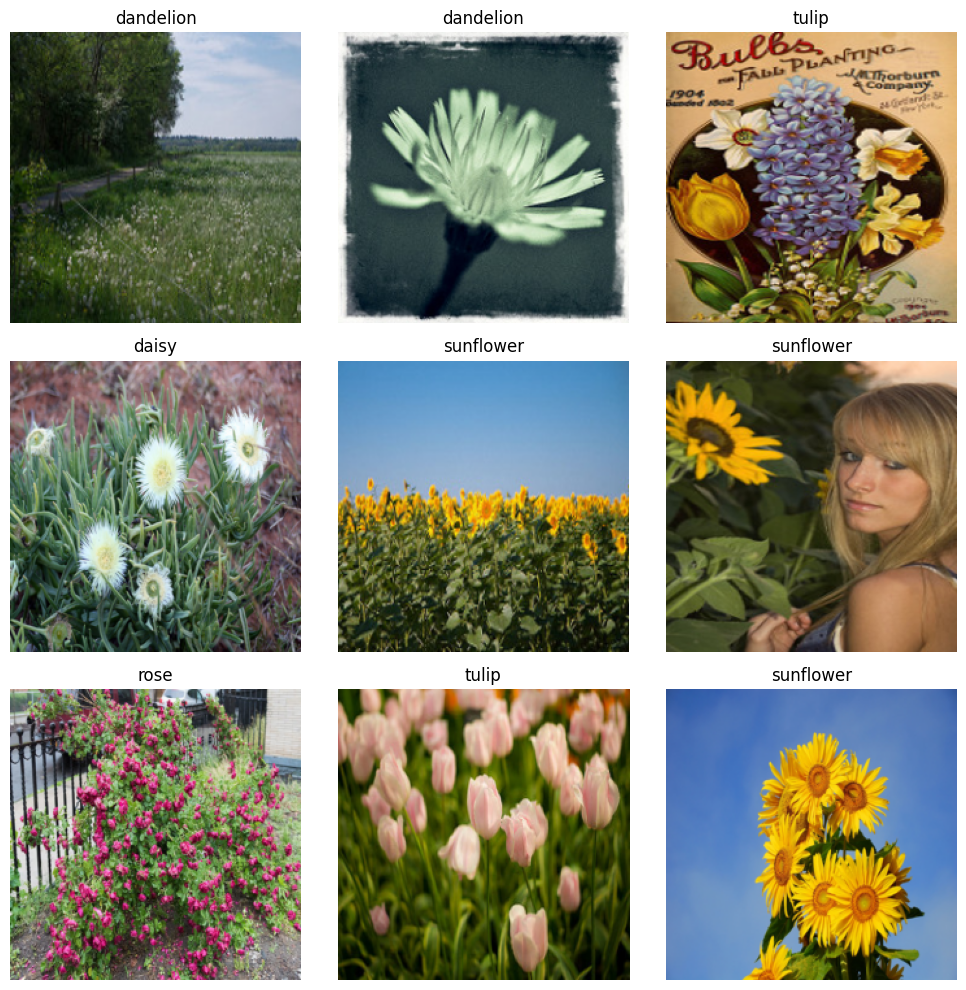

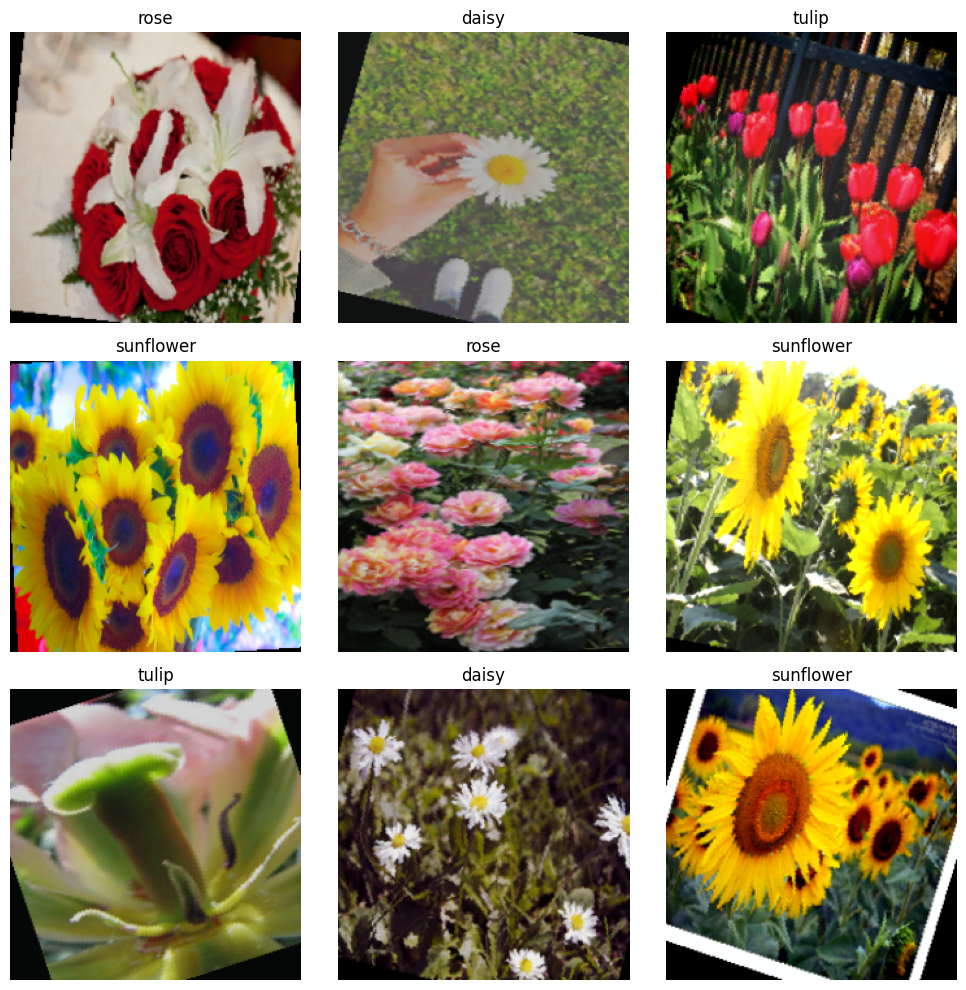

In [5]:
%run /content/drive/MyDrive/Colab_Notebooks/00_data_preprocessing.ipynb # Chạy notebook 1 để xây bộ train_loader, val_loader

In [6]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

In [7]:
print("Size of train data:", len(train_data))
print("Size of val data:", len(val_data))

Size of train data: 3453
Size of val data: 864


## **Xây dựng mô hình CNN**

In [8]:
class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 5)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [9]:
# Định nghĩa các lớp của model
model = CNNModel().to(device)

print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=5, bias=True)
  )
)


In [10]:
# Tạo hàm loss
criterion = nn.CrossEntropyLoss()

# Bộ tối ưu
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## **Huấn luyện CNN**

In [11]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    train_losses.append(running_loss)
    train_accs.append(train_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Accuracy: {train_acc:.2f}%")

Epoch 1
Train Accuracy: 42.63%
Epoch 2
Train Accuracy: 53.69%
Epoch 3
Train Accuracy: 58.88%
Epoch 4
Train Accuracy: 62.18%
Epoch 5
Train Accuracy: 64.70%
Epoch 6
Train Accuracy: 67.56%
Epoch 7
Train Accuracy: 68.20%
Epoch 8
Train Accuracy: 71.07%
Epoch 9
Train Accuracy: 69.59%
Epoch 10
Train Accuracy: 72.57%


## **Đánh giá mô hình CNN**


In [12]:
model.eval()

val_correct = 0
val_total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        val_total += labels.size(0)

        val_correct += (
            predicted == labels
        ).sum().item()

val_acc = 100 * val_correct / val_total

print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 69.79%


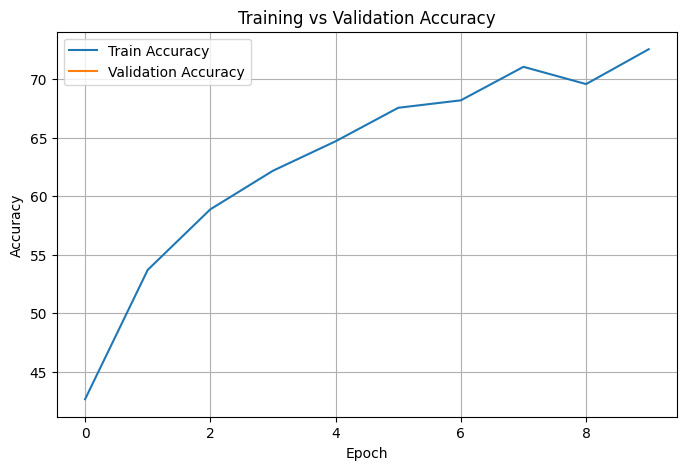

In [13]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

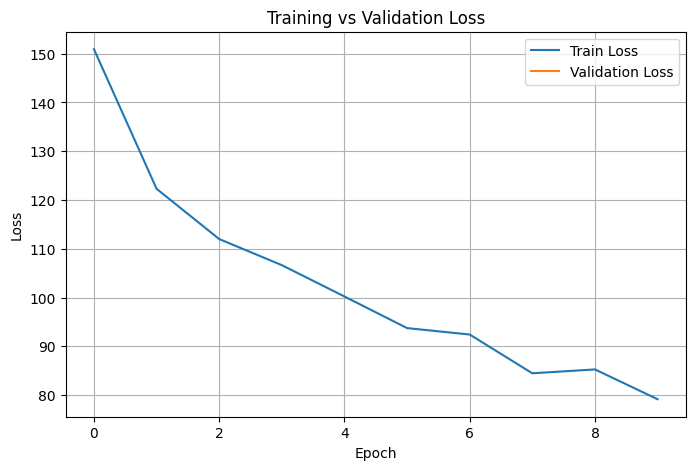

In [14]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

In [15]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [16]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[101  14   6   4   7]
 [ 19 142   4  24   6]
 [ 11  15  72   5  50]
 [  2   8   1 136   2]
 [  5  14  34  26 156]]


In [17]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

       daisy       0.73      0.77      0.75       132
   dandelion       0.74      0.73      0.73       195
        rose       0.62      0.47      0.53       153
   sunflower       0.70      0.91      0.79       149
       tulip       0.71      0.66      0.68       235

    accuracy                           0.70       864
   macro avg       0.70      0.71      0.70       864
weighted avg       0.70      0.70      0.70       864



## **Tổng kết**